In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '4500',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.252155, valid=0.239297, test=0.239146
	validation loss decreased (inf -> 0.239297), saving model ...
	epoch 2 losses: train=0.238977, valid=0.238892, test=0.238688
	validation loss decreased (0.239297 -> 0.238892), saving model ...
	epoch 3 losses: train=0.164275, valid=0.019636, test=0.019631
	validation loss decreased (0.238892 -> 0.019636), saving model ...
	epoch 4 losses: train=0.005544, valid=0.000896, test=0.000894
	validation loss decreased (0.019636 -> 0.000896), saving model ...
	epoch 5 losses: train=0.000488, valid=0.000322, test=0.000341
	validation loss decreased (0.000896 -> 0.000322), saving model ...
	epoch 6 losses: train=0.000195, valid=0.000107, test=0.000112
	validation loss decreased (0.000322 -> 0.000107), saving model ...
	epoch 7 losses: train=0.000079, valid=0.000058, test=0.000058
	validation loss decreased (0.000107 -> 0.000058), saving model ...
	epoch 8 losses: train=0.000048, valid=0.000050, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

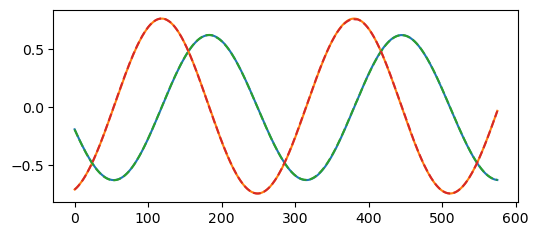

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.077333, valid=0.029321, test=0.029244
	validation loss decreased (inf -> 0.029321), saving model ...
	epoch 2 losses: train=0.026812, valid=0.023521, test=0.023393
	validation loss decreased (0.029321 -> 0.023521), saving model ...
	epoch 3 losses: train=0.023343, valid=0.023486, test=0.023380
	validation loss decreased (0.023521 -> 0.023486), saving model ...
	epoch 4 losses: train=0.023160, valid=0.023493, test=0.023350
	early stopping counter: 1 out of 10
	epoch 5 losses: train=0.023307, valid=0.023583, test=0.023488
	early stopping counter: 2 out of 10
	epoch 6 losses: train=0.023276, valid=0.023441, test=0.023349
	validation loss decreased (0.023486 -> 0.023441), saving model ...
	epoch 7 losses: train=0.023277, valid=0.023511, test=0.023338
	early stopping counter: 1 out of 10
	epoch 8 losses: train=0.023446, valid=0.023703, test=0.023547
	early stopping counter: 2 out of 10
	epoch 9 losses: train=0.023289, valid=0.023

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

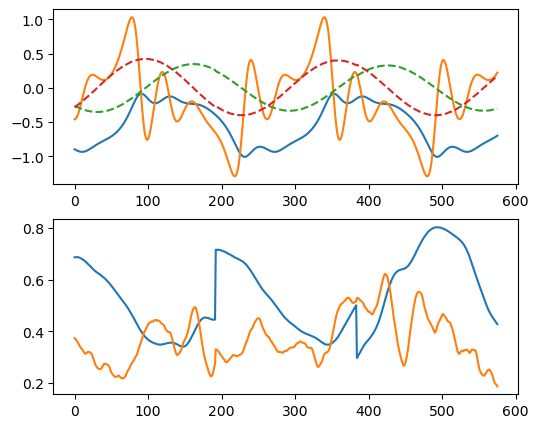

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.270313, valid=0.186131, test=0.186255
	validation loss decreased (inf -> 0.186131), saving model ...
	epoch 2 losses: train=0.185694, valid=0.182735, test=0.182513
	validation loss decreased (0.186131 -> 0.182735), saving model ...
	epoch 3 losses: train=0.175586, valid=0.153143, test=0.151882
	validation loss decreased (0.182735 -> 0.153143), saving model ...
	epoch 4 losses: train=0.122372, valid=0.079353, test=0.079318
	validation loss decreased (0.153143 -> 0.079353), saving model ...
	epoch 5 losses: train=0.073342, valid=0.070006, test=0.069919
	validation loss decreased (0.079353 -> 0.070006), saving model ...
	epoch 6 losses: train=0.067467, valid=0.062227, test=0.062253
	validation loss decreased (0.070006 -> 0.062227), saving model ...
	epoch 7 losses: train=0.055493, valid=0.052132, test=0.051589
	validation loss decreased (0.062227 -> 0.052132), saving model ...
	epoch 8 losses: train=0.044262, valid=0.040201, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

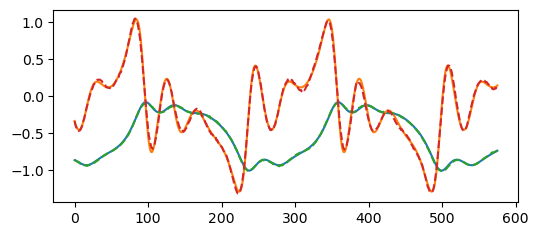

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.074854, valid=0.028070, test=0.028302
	validation loss decreased (inf -> 0.028070), saving model ...
	epoch 2 losses: train=0.027295, valid=0.027180, test=0.027387
	validation loss decreased (0.028070 -> 0.027180), saving model ...
	epoch 3 losses: train=0.026813, valid=0.027094, test=0.027347
	validation loss decreased (0.027180 -> 0.027094), saving model ...
	epoch 4 losses: train=0.026815, valid=0.026719, test=0.026953
	validation loss decreased (0.027094 -> 0.026719), saving model ...
	epoch 5 losses: train=0.026507, valid=0.026958, test=0.027081
	early stopping counter: 1 out of 10
	epoch 6 losses: train=0.026672, valid=0.026570, test=0.026775
	validation loss decreased (0.026719 -> 0.026570), saving model ...
	epoch 7 losses: train=0.025872, valid=0.025319, test=0.025578
	validation loss decreased (0.026570 -> 0.025319), saving model ...
	epoch 8 losses: train=0.024725, valid=0.024263, test=0.024574
	validation loss 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

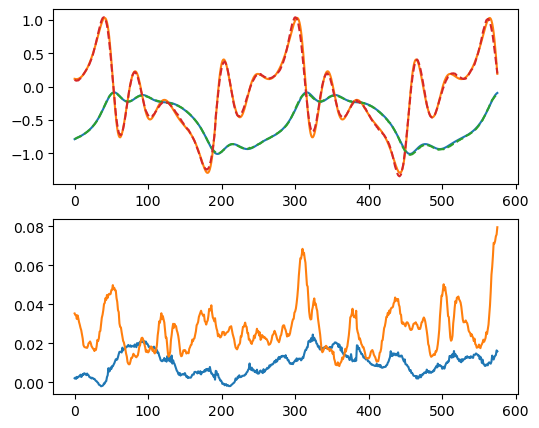

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

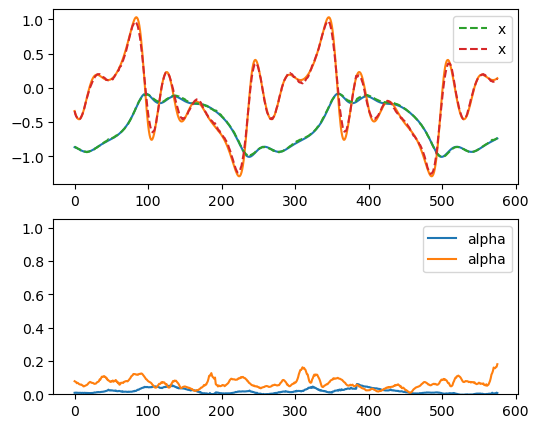

In [17]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break